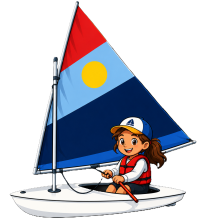

# Human Training Notebook
## Run on VS Code (or any local jupyter notebook enabled IDE) do not run this on Google Colab
---
## It's a battle between the humans and the PPO models.
### Both of you are considered tiny tackers (Human and PPO AI Agent). We need to determine who the better sailors are!
In this notebook you (the human) will learn how to sail in the environments yourself and compete with the PPO agents. 

### Objectives: 
1. Learn how to sail upwind
2. Learn how to sail on a broad reach in different directions
3. Learn how to jibe around a buoy
4. Learn how to sail downwind efficiently
5. Learn how to complete a race course by rounding buoys correctly. 


Note, before proceeding you may need to setup install the packages in the requirements.txt file. You can also find packages you may need in the model training notebook.



In [1]:
# Set your working directory correctly to ensure the notebook can find the data files
import os
import pandas as pd

# Move to repo root if notebook is in notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working directory:", os.getcwd())

Working directory: /Users/nicole.r.frank/tiny-tackers


Note: This notebook will ask you to compete with models/environments that were trained from in model training notebook. 
The models already available to you are the ones I initially found best for these challenges. 

When you are ready to create your own PPO models (tackers) you can head to the model_trainin.ipynb notebook yourself

More models and environments can be found in the graveyard folder. 

The graveyard folder = past models, environments, videos and notebooks used in the creation of this repository. 
These were the ones I moved away from in the process of widdling down to the ones I wanted to use for this project.


# Gabo-Tor's Upwind Competition

## How to sail upwind:

A sailor must zig zag in order to go upwind because it is impossible to sail directly into the wind. 
A sail generates lift, just like an airplane wing, when wind can move across both side of the sail and at the same time. 

If you sail directly into the wind, a sail acts simply as a flag, when you sail upwind but offset by around 30 degrees or more, one creates a cupped sail shape. 
In that shape wind can move over the front and back of the sail and generate lift. Sailing at an angle around 45 degrees away from the wind is called a close haul. 

You must sail at a close haul in a zig zag pattern in order to reach the orange buoy.


## Environment Details and Objectives
* WIND: The wind is coming from the north end of the environment blowing towards the south end. 
* TARGET: The orange buoy
* EVALUATION: reach the orange buoy in fewer timesteps than the PPO agent trained on this environment
* ENVIRONMENT AUTHOR: Gabo-Tor
* Environment code including reward structure that applies to the PPO agent can be sound in the gym_sailing_environments folder
### Alright tiny tackers! on your marks, get set, go!



In [3]:
# Human goes first!
!python tiny_tackers/human_base_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sailing from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sailing_gabo-tor/gym_sailing/__init__.py
Human controls:
LEFT arrow = steer left
RIGHT arrow = steer right
SPACE = start
ESC = quit episode
Saved human score:
{'agent': 'Human', 'total_reward': np.float64(352.5151220293746), 'timesteps': 1269}


Note: your reward and timesteps is automatically saved in the data/results folder :) It will be compared to the AI tiny tacker when it's finished

In [5]:
# It's the PPO AI tiny tacker's turn!
!python tiny_tackers/ppo_base_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sailing from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sailing_gabo-tor/gym_sailing/__init__.py
PPO Base Model running...
ESC = quit episode
Saved PPO score:
{'agent': 'PPO Base Model', 'total_reward': np.float64(356.1676408952842), 'timesteps': 1241}


Let's see who won on this environment!

In [6]:
human_score = pd.read_csv("data/results/human_score.csv")
ppo_score = pd.read_csv("data/results/ppo_score.csv")

results = pd.concat([human_score, ppo_score], ignore_index=True)

# Winner by FEWEST timesteps
results["winner_by_timesteps"] = results["timesteps"] == results["timesteps"].min()

winner = results.loc[results["timesteps"].idxmin()]

display(results)

print(f"Winner: {winner['agent']}")
print(f"Timesteps: {winner['timesteps']}")
print(f"Reward: {winner['total_reward']:.2f}")

,agent,total_reward,timesteps,winner_by_timesteps
0,Human,352.515122,1269,False
1,PPO Base Model,356.167641,1241,True


Winner: PPO Base Model
Timesteps: 1241
Reward: 356.17


If you lost to the base model here, I recommend you brush up on your strategy!! 
The rewards are an accumulation of the signals gathered in training, but thyey don't necesarily mean you had a etter or worse run. 
For instance, I may have a higher reward than the PPO but complete the environment in fewer timesetsps. While this is rare, it could be something you explore when creating your own reward structures to train even better agents!!


Good luck in the challenges ahead. These environments were created by me, and each learning task is mean to train you and the PPO agent to complete a triangle race course! Remember, the PO agent has already been trained in each (you can review which model it loads in the tiny-tackers folder). To do your own PPO agent tiny tacker training head to the model_training notebook :) 
* Note, if you create your own model, navigate to the scripts in tiny_tackers to replace the model path with whatever new model path you've created :) 



---
END

---

# Gym_Sail_Steps Upwind Competition
## How to sail upwind:

A sailor must zig zag in order to go upwind because it is impossible to sail directly into the wind. 
A sail generates lift, just like an airplane wing, when wind can move across both side of the sail and at the same time. 

If you sail directly into the wind, a sail acts simply as a flag, when you sail upwind but offset by around 30 degrees or more, one creates a cupped sail shape. 
In that shape wind can move over the front and back of the sail and generate lift. Sailing at an angle around 45 degrees away from the wind is called a close haul. 

You must sail at a close haul in a zig zag pattern in order to reach the orange buoy.

## Environment Details and Objectives
* WIND: The wind is coming from the north end of the environment blowing towards the south end. 
* TARGET: The green dot next to the orange buoy. The green dot is in a location ideal for the triangle racing environment you are working up to
* EVALUATION: reach the green dot in fewer timesteps than the PPO agent trained on this environment
* ENVIRONMENT AUTHOR: Nikki Frank
* Environment code including reward structure that applies to the PPO agent can be sound in the gym_sailing_environments folder
### Alright tiny tackers! on your marks, get set, go!



In [8]:
# Human goes first!
!python tiny_tackers/human_upwind_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
Created environment: SailboatEnvUpwind
Environment id: SailboatUpwind-v0
Human controls:
LEFT arrow = steer left
RIGHT arrow = steer right
SPACE = start
ESC = quit episode
Saved human score:
{'agent': 'Human Race', 'env_id': 'SailboatUpwind-v0', 'total_reward': np.float64(351.6404355858159), 'timesteps': 875}


Note: your reward and timesteps is automatically saved in the data/results folder :) It will be compared to the AI tiny tacker when it's finished

In [9]:
# It's the PPO AI tiny tacker's turn!
!python tiny_tackers/ppo_upwind_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
PPO Upwind Model running...
ESC = quit episode
Saved PPO score:
{'agent': 'PPO Upwind Model', 'env_id': 'SailboatUpwind-v0', 'model_path': 'models/ppo/upwind_step/ppo_upwind_step_1M.zip', 'total_reward': np.float64(311.1221417769609), 'timesteps': 1286}


Let's see who won on this environment!

In [10]:
human_score = pd.read_csv("data/results/human_upwind_score.csv")
ppo_score = pd.read_csv("data/results/ppo_upwind_score.csv")

results = pd.concat([human_score, ppo_score], ignore_index=True)

# Winner by FEWEST timesteps
results["winner_by_timesteps"] = results["timesteps"] == results["timesteps"].min()

winner = results.loc[results["timesteps"].idxmin()]

display(results)

print(f"Winner: {winner['agent']}")
print(f"Timesteps: {winner['timesteps']}")
print(f"Reward: {winner['total_reward']:.2f}")

,agent,env_id,total_reward,timesteps,model_path,winner_by_timesteps
0,Human Race,SailboatUpwind-v0,351.640436,875,NaN,True
1,PPO Upwind Model,SailboatUpwind-v0,311.122142,1286,models/ppo/upwind_step/ppo_upwind_step_1M.zip,False


Winner: Human Race
Timesteps: 875
Reward: 351.64


---
END

---

# Gym_Sail_Steps Windward to Reach Competition
## How to sail in this situation:

A sail generates lift, just like an airplane wing, when wind can move across both side of the sail and at the same time. 

When sailing from your current location to a point southwest of you (in a world where north is always up), you should maintain a heading approximately 135 degrees away from the wind. 
Note: in downwind scenarios it is faster to sail 135 degrees away from the wind than 180 degrees away from the wind!
* If you sail directly downwind (180 degrees) you have eliminated you sail's ability to act like an airplane wing generating lift. Instead, your sail becomes no more than a parachute. The wind blows you where you are heading, but you are not able to eek out extra speed. Keep this in mind in the next few environments! 
* Also, you may have learned already that fewer turns is typically efficient than more turns.


## Environment Details and Objectives
* WIND: The wind is coming from the north end of the environment blowing towards the south end. 
* TARGET: The green dot next to the orange buoy. The green dot is in a location ideal for the triangle racing environment you are working up to
* EVALUATION: reach the green dot in fewer timesteps than the PPO agent trained on this environment
* ENVIRONMENT AUTHOR: Nikki Frank
* Environment code including reward structure that applies to the PPO agent can be sound in the gym_sailing_environments folder
### Alright tiny tackers! on your marks, get set, go!



In [11]:
# Human goes first!
!python tiny_tackers/human_windward_to_reach_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
Created environment: SailboatEnvWindwardToReach
Environment id: SailboatWindwardToReach-v0
Human controls:
LEFT arrow = steer left
RIGHT arrow = steer right
SPACE = start
ESC = quit episode
Saved human score:
{'agent': 'Human', 'env_id': 'SailboatWindwardToReach-v0', 'total_reward': np.float64(215.51551327805117), 'timesteps': 537}


Note: your reward and timesteps is automatically saved in the data/results folder :) It will be compared to the AI tiny tacker when it's finished

In [17]:
# It's the PPO AI tiny tacker's turn!
!python tiny_tackers/ppo_windward_to_reach_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
PPO Windward to Reach Model running...
ESC = quit episode
Saved PPO score:
{'agent': 'PPO Windward to Reach Model', 'env_id': 'SailboatWindwardToReach-v0', 'model_path': 'models/ppo/windward_to_reach_step/ppo_upwind_1M_windwardtoreach_250K.zip', 'total_reward': np.float64(254.32951563684367), 'timesteps': 218}


Let's see who won on this environment!

In [18]:
human_score = pd.read_csv("data/results/human_windward_to_reach_score.csv")
ppo_score = pd.read_csv("data/results/ppo_windward_to_reach_score.csv")

results = pd.concat([human_score, ppo_score], ignore_index=True)

# Winner by FEWEST timesteps
results["winner_by_timesteps"] = results["timesteps"] == results["timesteps"].min()

winner = results.loc[results["timesteps"].idxmin()]

display(results)

print(f"Winner: {winner['agent']}")
print(f"Timesteps: {winner['timesteps']}")
print(f"Reward: {winner['total_reward']:.2f}")

,agent,env_id,total_reward,timesteps,model_path,winner_by_timesteps
0,Human,SailboatWindwardToReach-v0,215.515513,537,NaN,False
1,PPO Windward to Reach Model,SailboatWindwardToReach-v0,254.329516,218,models/ppo/windward_to_reach_step/ppo_upwind_1...,True


Winner: PPO Windward to Reach Model
Timesteps: 218
Reward: 254.33


---
END

---

# Gym_Sail_Steps Reach to Downwind Competition
## How to sail in this situation:

This is similar to the previous environment, but this time you need to travel to a point south east of your starting position :) 


## Environment Details and Objectives
* WIND: The wind is coming from the north end of the environment blowing towards the south end. 
* TARGET: The green dot next to the orange buoy. The green dot is in a location ideal for the triangle racing environment you are working up to
* EVALUATION: reach the green dot in fewer timesteps than the PPO agent trained on this environment
* ENVIRONMENT AUTHOR: Nikki Frank
* Environment code including reward structure that applies to the PPO agent can be sound in the gym_sailing_environments folder
### Alright tiny tackers! on your marks, get set, go!



In [24]:
# Human goes first!
!python tiny_tackers/human_reach_to_downwind_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
Created environment: SailboatEnvReachToDownwind
Environment id: SailboatReachToDownwind-v0
Human controls:
LEFT arrow = steer left
RIGHT arrow = steer right
SPACE = start
ESC = quit episode
Saved human score:
{'agent': 'Human', 'env_id': 'SailboatReachToDownwind-v0', 'total_reward': np.float64(288.06708588585616), 'timesteps': 284}


Note: your reward and timesteps is automatically saved in the data/results folder :) It will be compared to the AI tiny tacker when it's finished

In [25]:
# It's the PPO AI tiny tacker's turn!
!python tiny_tackers/ppo_reach_to_downwind_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
PPO Reach to Downwind Model running...
ESC = quit episode
Saved PPO score:
{'agent': 'PPO Reach to Downwind Model', 'env_id': 'SailboatReachToDownwind-v0', 'model_path': 'models/ppo/reach_to_downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K.zip', 'total_reward': np.float64(252.51891281977208), 'timesteps': 225}


Let's see who won on this environment!

In [26]:
human_score = pd.read_csv("data/results/human_reach_to_downwind_score.csv")
ppo_score = pd.read_csv("data/results/ppo_reach_to_downwind_score.csv")

results = pd.concat([human_score, ppo_score], ignore_index=True)

# Winner by FEWEST timesteps
results["winner_by_timesteps"] = results["timesteps"] == results["timesteps"].min()

winner = results.loc[results["timesteps"].idxmin()]

display(results)

print(f"Winner: {winner['agent']}")
print(f"Timesteps: {winner['timesteps']}")
print(f"Reward: {winner['total_reward']:.2f}")

,agent,env_id,total_reward,timesteps,model_path,winner_by_timesteps
0,Human,SailboatReachToDownwind-v0,288.067086,284,NaN,False
1,PPO Reach to Downwind Model,SailboatReachToDownwind-v0,252.518913,225,models/ppo/reach_to_downwind_step/ppo_upwind_1...,True


Winner: PPO Reach to Downwind Model
Timesteps: 225
Reward: 252.52


---
END

---

# Gym_Sail_Steps Downwind Competition
## How to sail downwind:

Recall, that sailing directly downwind will not yeild the highest boat speed. In this environment you will go from a northern point to a southern target, but you may find that jibing through the dead-downwind zone is an effective way to maintain a high speed while also remaining on an optimial path. 
* In other words, you can zig zag down wind just like you did upwind. I recommend trying this a few times to find an optimal course 


## Environment Details and Objectives
* WIND: The wind is coming from the north end of the environment blowing towards the south end. 
* TARGET: The green dot next to the orange buoy. The green dot is in a location ideal for the triangle racing environment you are working up to
* EVALUATION: reach the green dot in fewer timesteps than the PPO agent trained on this environment
* ENVIRONMENT AUTHOR: Nikki Frank
* Environment code including reward structure that applies to the PPO agent can be sound in the gym_sailing_environments folder
### Alright tiny tackers! on your marks, get set, go!



In [29]:
# Human goes first!
!python tiny_tackers/human_downwind_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
Created environment: SailboatEnvDownwind
Environment id: SailboatDownwind-v0
Human controls:
LEFT arrow = steer left
RIGHT arrow = steer right
SPACE = start
ESC = quit episode
Saved human score:
{'agent': 'Human', 'env_id': 'SailboatDownwind-v0', 'total_reward': np.float64(396.7700063784542), 'timesteps': 442}


Note: your reward and timesteps is automatically saved in the data/results folder :) It will be compared to the AI tiny tacker when it's finished

In [30]:
# It's the PPO AI tiny tacker's turn!
!python tiny_tackers/ppo_downwind_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
PPO Downwind Model running...
ESC = quit episode
Saved PPO score:
{'agent': 'PPO Downwind Model', 'env_id': 'SailboatDownwind-v0', 'model_path': 'models/ppo/downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K.zip', 'total_reward': np.float64(353.0055715422424), 'timesteps': 876}


Let's see who won on this environment!

In [31]:
human_score = pd.read_csv("data/results/human_downwind_score.csv")
ppo_score = pd.read_csv("data/results/ppo_downwind_score.csv")

results = pd.concat([human_score, ppo_score], ignore_index=True)

# Winner by FEWEST timesteps
results["winner_by_timesteps"] = results["timesteps"] == results["timesteps"].min()

winner = results.loc[results["timesteps"].idxmin()]

display(results)

print(f"Winner: {winner['agent']}")
print(f"Timesteps: {winner['timesteps']}")
print(f"Reward: {winner['total_reward']:.2f}")

,agent,env_id,total_reward,timesteps,model_path,winner_by_timesteps
0,Human,SailboatDownwind-v0,396.770006,442,NaN,True
1,PPO Downwind Model,SailboatDownwind-v0,353.005572,876,models/ppo/downwind_step/ppo_upwind_1M_windwar...,False


Winner: Human
Timesteps: 442
Reward: 396.77


---
END

---

# Gym_Sail_Steps Olympic Triangle Competition
## How to sail the traingle racecourse:

Here you will put all the skills you've learned together. You must complete the following objectives in order:
1. Sail from a leeward (downwind) buoy to a windward buoy target point
2. Sail from the windward buoy to the reach buoy target point
3. Sail from the reach buoy to the leeward buoy target point
4. Sail from the leeward buoy to the windward buoy
5. Sail from the windward buoy to the leeward buoy target point
6. Sail from the leeward buoy to the windward buoy target point to complete the race!

### Rule! you must go around each buoy, ideally on the port side of the boat. 
Note: if using my trained models, I would expect a human to outperform the ppo!


## Environment Details and Objectives
* WIND: The wind is coming from the north end of the environment blowing towards the south end. 
* TARGET: The green dot next to the orange buoy. The green dot is in a location ideal for the triangle racing environment you are working up to
* EVALUATION: reach the green dot in fewer timesteps than the PPO agent trained on this environment
* ENVIRONMENT AUTHOR: Nikki Frank
* Environment code including reward structure that applies to the PPO agent can be sound in the gym_sailing_environments folder
### Alright tiny tackers! on your marks, get set, go!



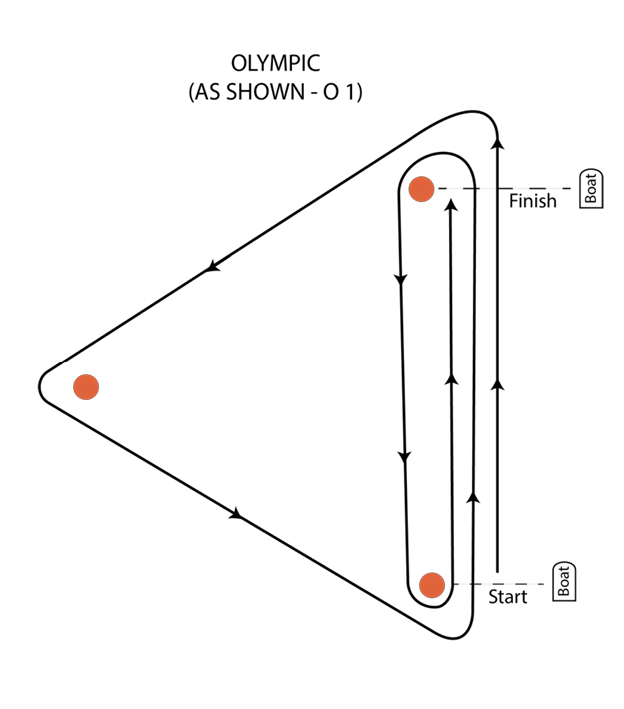

In [33]:
# view the traingle race course
from IPython.display import Image, display

display(
    Image(
        "./images/olympic_triangle.png",
        width=300
    )
)

In [34]:
# Human goes first!
!python tiny_tackers/human_triangle_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
Created environment: SailboatEnvTriangle
Environment id: SailboatTriangle-v0
Human controls:
LEFT arrow = steer left
RIGHT arrow = steer right
SPACE = start
ESC = quit episode
Saved human score:
{'agent': 'Human', 'env_id': 'SailboatTriangle-v0', 'total_reward': np.float64(2093.0810486864398), 'timesteps': 4122}


Note: your reward and timesteps is automatically saved in the data/results folder :) It will be compared to the AI tiny tacker when it's finished

In [37]:
# It's the PPO AI tiny tacker's turn!
!python tiny_tackers/ppo_triangle_tt.py

/Users/nicole.r.frank/tiny-tackers/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Loaded gym_sail_steps from: /Users/nicole.r.frank/tiny-tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py
PPO Triangle Model running...
ESC = quit episode
Saved PPO score:
{'agent': 'PPO Triangle Model', 'env_id': 'SailboatTriangle-v0', 'model_path': 'models/ppo/triangle_race_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K_triangle_2M.zip', 'total_reward': np.float64(1547.856576431334), 'timesteps': 9673}


Let's see who won on this environment!

In [38]:
human_score = pd.read_csv("data/results/human_triangle_score.csv")
ppo_score = pd.read_csv("data/results/ppo_triangle_score.csv")

results = pd.concat([human_score, ppo_score], ignore_index=True)

# Winner by FEWEST timesteps
results["winner_by_timesteps"] = results["timesteps"] == results["timesteps"].min()

winner = results.loc[results["timesteps"].idxmin()]

display(results)

print(f"Winner: {winner['agent']}")
print(f"Timesteps: {winner['timesteps']}")
print(f"Reward: {winner['total_reward']:.2f}")

,agent,env_id,total_reward,timesteps,model_path,winner_by_timesteps
0,Human,SailboatTriangle-v0,2093.081049,4122,NaN,True
1,PPO Triangle Model,SailboatTriangle-v0,1547.856576,9673,models/ppo/triangle_race_step/ppo_upwind_1M_wi...,False


Winner: Human
Timesteps: 4122
Reward: 2093.08


---
END

---